# Automatic Short Answer Scoring — Mohler Dataset
### Pipeline: Preprocessing → Feature Engineering → Multi-Model Training → Evaluation

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import re
import warnings
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import shap

from sentence_transformers import SentenceTransformer
from sklearn.model_selection import KFold
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectFromModel
from scipy.stats import pearsonr, wilcoxon
from sklearn.metrics import mean_absolute_error, cohen_kappa_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

warnings.filterwarnings('ignore')

RANDOM_SEED = 6
np.random.seed(RANDOM_SEED)

plt.rcParams.update({
    'font.size': 11, 'axes.titlesize': 14, 'axes.labelsize': 12,
    'legend.fontsize': 11, 'xtick.labelsize': 10, 'ytick.labelsize': 10,
    'figure.dpi': 300, 'savefig.dpi': 300, 'savefig.bbox': 'tight'
})
sns.set_theme(style="whitegrid")

d:\Documents\jean\sem 5\deep learning\deep_learn_new\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Load Dataset

In [2]:
file_path = 'Mohler_dataset_hf/Mohler_dataset_hf/data/raw-oe-00001.parquet'
df = pd.read_parquet(file_path)

df['score_avg'] = (df['score_grader_1'] + df['score_grader_2']) / 2

df = df[df['score_avg'] <= 5.0].reset_index(drop=True)

print(f"Total data after filter: {len(df)}")
print(f"Score range: {df['score_avg'].min():.1f} – {df['score_avg'].max():.1f}")

Total data after filter: 1809
Score range: 0.0 – 5.0


## 3. Preprocessing
> clean

In [3]:
def preprocessing(text):
    if text is None or not isinstance(text, str):
        return ""
    text = text.strip().lower()
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['instructor_answer_clean'] = df['instructor_answer'].apply(preprocessing)
df['student_answer_clean']    = df['student_answer'].apply(preprocessing)

embedder = SentenceTransformer("all-mpnet-base-v2")
student_emb = embedder.encode(df['student_answer_clean'].tolist(), show_progress_bar=True, batch_size=64)
instructor_emb = embedder.encode(df['instructor_answer_clean'].tolist(), show_progress_bar=True, batch_size=64)

Batches: 100%|██████████| 29/29 [03:05<00:00,  6.40s/it]


## 4. Feature Engineering Modular (for ablation study)
>pisahin pembuatan fitur jd struktur dictionary so ablation study bs diuji per klmpok

In [4]:
def get_word_overlap_features(text1, text2):
    set1, set2 = set(text1.split()), set(text2.split())
    if not set1 or not set2: return 0.0, 0.0, 0.0
    intersection, union = set1 & set2, set1 | set2
    jaccard = len(intersection) / len(union)
    recall = len(intersection) / len(set2)
    f1 = len(intersection) / len(set1) if set1 else 0.0
    return jaccard, recall, f1

def build_feature_dict(student_emb, instructor_emb, student_texts, instructor_texts):
    cos_sim = cosine_similarity(student_emb, instructor_emb).diagonal().reshape(-1, 1)
    emb_diff = np.abs(student_emb - instructor_emb)
    emb_prod = student_emb * instructor_emb
    euc_dist = np.linalg.norm(student_emb - instructor_emb, axis=1).reshape(-1, 1)
    
    len_student = np.array([len(t.split()) for t in student_texts]).reshape(-1, 1)
    len_instr = np.array([len(t.split()) for t in instructor_texts]).reshape(-1, 1)
    len_ratio = len_student / (len_instr + 1)
    len_diff = np.abs(len_student - len_instr)
    
    overlap_feats = np.array([get_word_overlap_features(s, i) for s, i in zip(student_texts, instructor_texts)])
    
    return {
        "embedding": np.hstack([cos_sim, euc_dist, emb_diff, emb_prod]),
        "lexical": overlap_feats,
        "length": np.hstack([len_student, len_instr, len_ratio, len_diff])
    }

feature_dict = build_feature_dict(student_emb, instructor_emb, df['student_answer_clean'].tolist(), df['instructor_answer_clean'].tolist())

X_all = np.hstack([feature_dict["embedding"], feature_dict["lexical"], feature_dict["length"]])
y_all = df['score_avg'].values
print(f"Total Feature Matrix Shape: {X_all.shape}")

Total Feature Matrix Shape: (1809, 1545)


## 5. K fold cross val, feature selection, and eval baseline
> using 5fold cv

In [5]:
def evaluate_metrics(y_true, y_pred):
    pearson, _ = pearsonr(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    # Thresholding kontinu ke diskrit (0-5)
    y_true_int = np.clip(np.rint(y_true).astype(int), 0, 5)
    y_pred_int = np.clip(np.rint(y_pred).astype(int), 0, 5)
    qwk = cohen_kappa_score(y_true_int, y_pred_int, weights="quadratic")
    return pearson, mae, qwk

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

models = {
    "Baseline: Linear Reg": LinearRegression(),
    "Baseline: SVR": SVR(kernel='rbf', C=1.0),
    "Ridge Regression": Ridge(alpha=10.0),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=500, learning_rate=0.05, max_depth=4, random_state=RANDOM_SEED),
    "LightGBM": LGBMRegressor(n_estimators=500, learning_rate=0.05, max_depth=-1, num_leaves=63, random_state=RANDOM_SEED, verbose=-1),
    "XGBoost (Proposed)": XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=5, random_state=RANDOM_SEED)
}

results_cv = {m: {'pearson': [], 'mae': [], 'qwk': [], 'errors': []} for m in models}

print("Running 5-Fold CV with Feature Selection...")
for fold, (train_idx, test_idx) in enumerate(kf.split(X_all)):
    X_train, X_test = X_all[train_idx], X_all[test_idx]
    y_train, y_test = y_all[train_idx], y_all[test_idx]
    
    # Feature Selection (Hanya dipelajari dari X_train untuk mencegah kebocoran data)
    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc = scaler.transform(X_test)
    
    selector = SelectFromModel(Ridge(alpha=1.0), max_features=300)
    X_train_sel = selector.fit_transform(X_train_sc, y_train)
    X_test_sel = selector.transform(X_test_sc)
    
    for name, model in models.items():
        model.fit(X_train_sel, y_train)
        preds = model.predict(X_test_sel)
            
        p, m, q = evaluate_metrics(y_test, preds)
        results_cv[name]['pearson'].append(p)
        results_cv[name]['mae'].append(m)
        results_cv[name]['qwk'].append(q)
        results_cv[name]['errors'].extend(np.abs(y_test - preds))

print("\n=== K-FOLD CROSS VALIDATION RESULTS ===")
summary_list = []
for name in models:
    summary_list.append({
        "Model": name,
        "Pearson": np.mean(results_cv[name]['pearson']),
        "MAE": np.mean(results_cv[name]['mae']),
        "QWK": np.mean(results_cv[name]['qwk'])
    })
summary_df = pd.DataFrame(summary_list).sort_values(by="Pearson", ascending=False).set_index("Model")
print(summary_df.round(4))

Running 5-Fold CV with Feature Selection...

=== K-FOLD CROSS VALIDATION RESULTS ===
                      Pearson     MAE     QWK
Model                                        
Baseline: SVR          0.6830  0.5529  0.5569
LightGBM               0.6808  0.5604  0.5917
XGBoost (Proposed)     0.6782  0.5618  0.5865
Gradient Boosting      0.6705  0.5674  0.6041
Ridge Regression       0.5461  0.7187  0.5126
Baseline: Linear Reg   0.5399  0.7276  0.5120


## 6. Ablation Study (K-Fold pada Kelompok Fitur)
> uji performa XGBoost if only diberikan fitur-fitur spesifik

In [6]:
ablation_groups = {
    "Embeddings Only": feature_dict["embedding"],
    "Lexical Only": feature_dict["lexical"],
    "Length Only": feature_dict["length"]
}

ablation_results = []
print("\n=== ABLATION STUDY (XGBoost 5-Fold) ===")
for group_name, X_group in ablation_groups.items():
    p_scores, m_scores = [], []
    for train_idx, test_idx in kf.split(X_group):
        X_tr, X_te = X_group[train_idx], X_group[test_idx]
        y_tr, y_te = y_all[train_idx], y_all[test_idx]
        
        xgb_abl = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=5, random_state=RANDOM_SEED)
        xgb_abl.fit(X_tr, y_tr)
        preds = xgb_abl.predict(X_te)
        
        p, m, _ = evaluate_metrics(y_te, preds)
        p_scores.append(p)
        m_scores.append(m)
        
    p_mean, m_mean = np.mean(p_scores), np.mean(m_scores)
    ablation_results.append({'Feature Group': group_name, 'Pearson (↑)': p_mean, 'MAE (↓)': m_mean})
    print(f"[{group_name}] Pearson: {p_mean:.4f} | MAE: {m_mean:.4f}")

# Menambahkan hasil Full Model dari K-Fold sebelumnya untuk perbandingan
ablation_results.append({
    'Feature Group': 'All Features (Proposed)', 
    'Pearson (↑)': summary_df.loc['XGBoost (Proposed)', 'Pearson'], 
    'MAE (↓)': summary_df.loc['XGBoost (Proposed)', 'MAE']
})
df_ablation = pd.DataFrame(ablation_results)


=== ABLATION STUDY (XGBoost 5-Fold) ===
[Embeddings Only] Pearson: 0.6608 | MAE: 0.5818
[Lexical Only] Pearson: 0.4769 | MAE: 0.6925
[Length Only] Pearson: 0.2987 | MAE: 0.8097


## 7. Statistical Test & Error Analysis

In [7]:
# Uji Wilcoxon antara error XGBoost dan Linear Regression
err_xgb = results_cv["XGBoost (Proposed)"]['errors']
err_lin = results_cv["Baseline: Linear Reg"]['errors']

stat, p_value = wilcoxon(err_xgb, err_lin)
print(f"\n=== UJI SIGNIFIKANSI (Wilcoxon Signed-Rank Test) ===")
print(f"p-value: {p_value:.4e}")
if p_value < 0.05:
    print("Kesimpulan: XGBoost secara SIGNIFIKAN lebih baik dibandingkan Baseline Linear Regression.")
else:
    print("Kesimpulan: Tidak ada perbedaan signifikan.")

# Simulasi Prediksi In-Sample untuk ekstraksi data dengan error ekstrem
scaler_full = StandardScaler()
X_full_sc = scaler_full.fit_transform(X_all)
selector_full = SelectFromModel(Ridge(alpha=1.0), max_features=300)
X_full_sel = selector_full.fit_transform(X_full_sc, y_all)

xgb_full = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=5, random_state=RANDOM_SEED)
xgb_full.fit(X_full_sel, y_all)
df['prediction'] = xgb_full.predict(X_full_sel)
df['abs_error'] = np.abs(df['score_avg'] - df['prediction'])

error_cases = df[df['abs_error'] > 1.5][['student_answer', 'instructor_answer', 'score_avg', 'prediction', 'abs_error']]
error_cases.to_csv("error_analysis_data.csv", index=False)
print(f"\nBerhasil mengekspor {len(error_cases)} baris error tinggi ke 'error_analysis_data.csv'")


=== UJI SIGNIFIKANSI (Wilcoxon Signed-Rank Test) ===
p-value: 7.5203e-46
Kesimpulan: XGBoost secara SIGNIFIKAN lebih baik dibandingkan Baseline Linear Regression.

Berhasil mengekspor 0 baris error tinggi ke 'error_analysis_data.csv'


### visualization

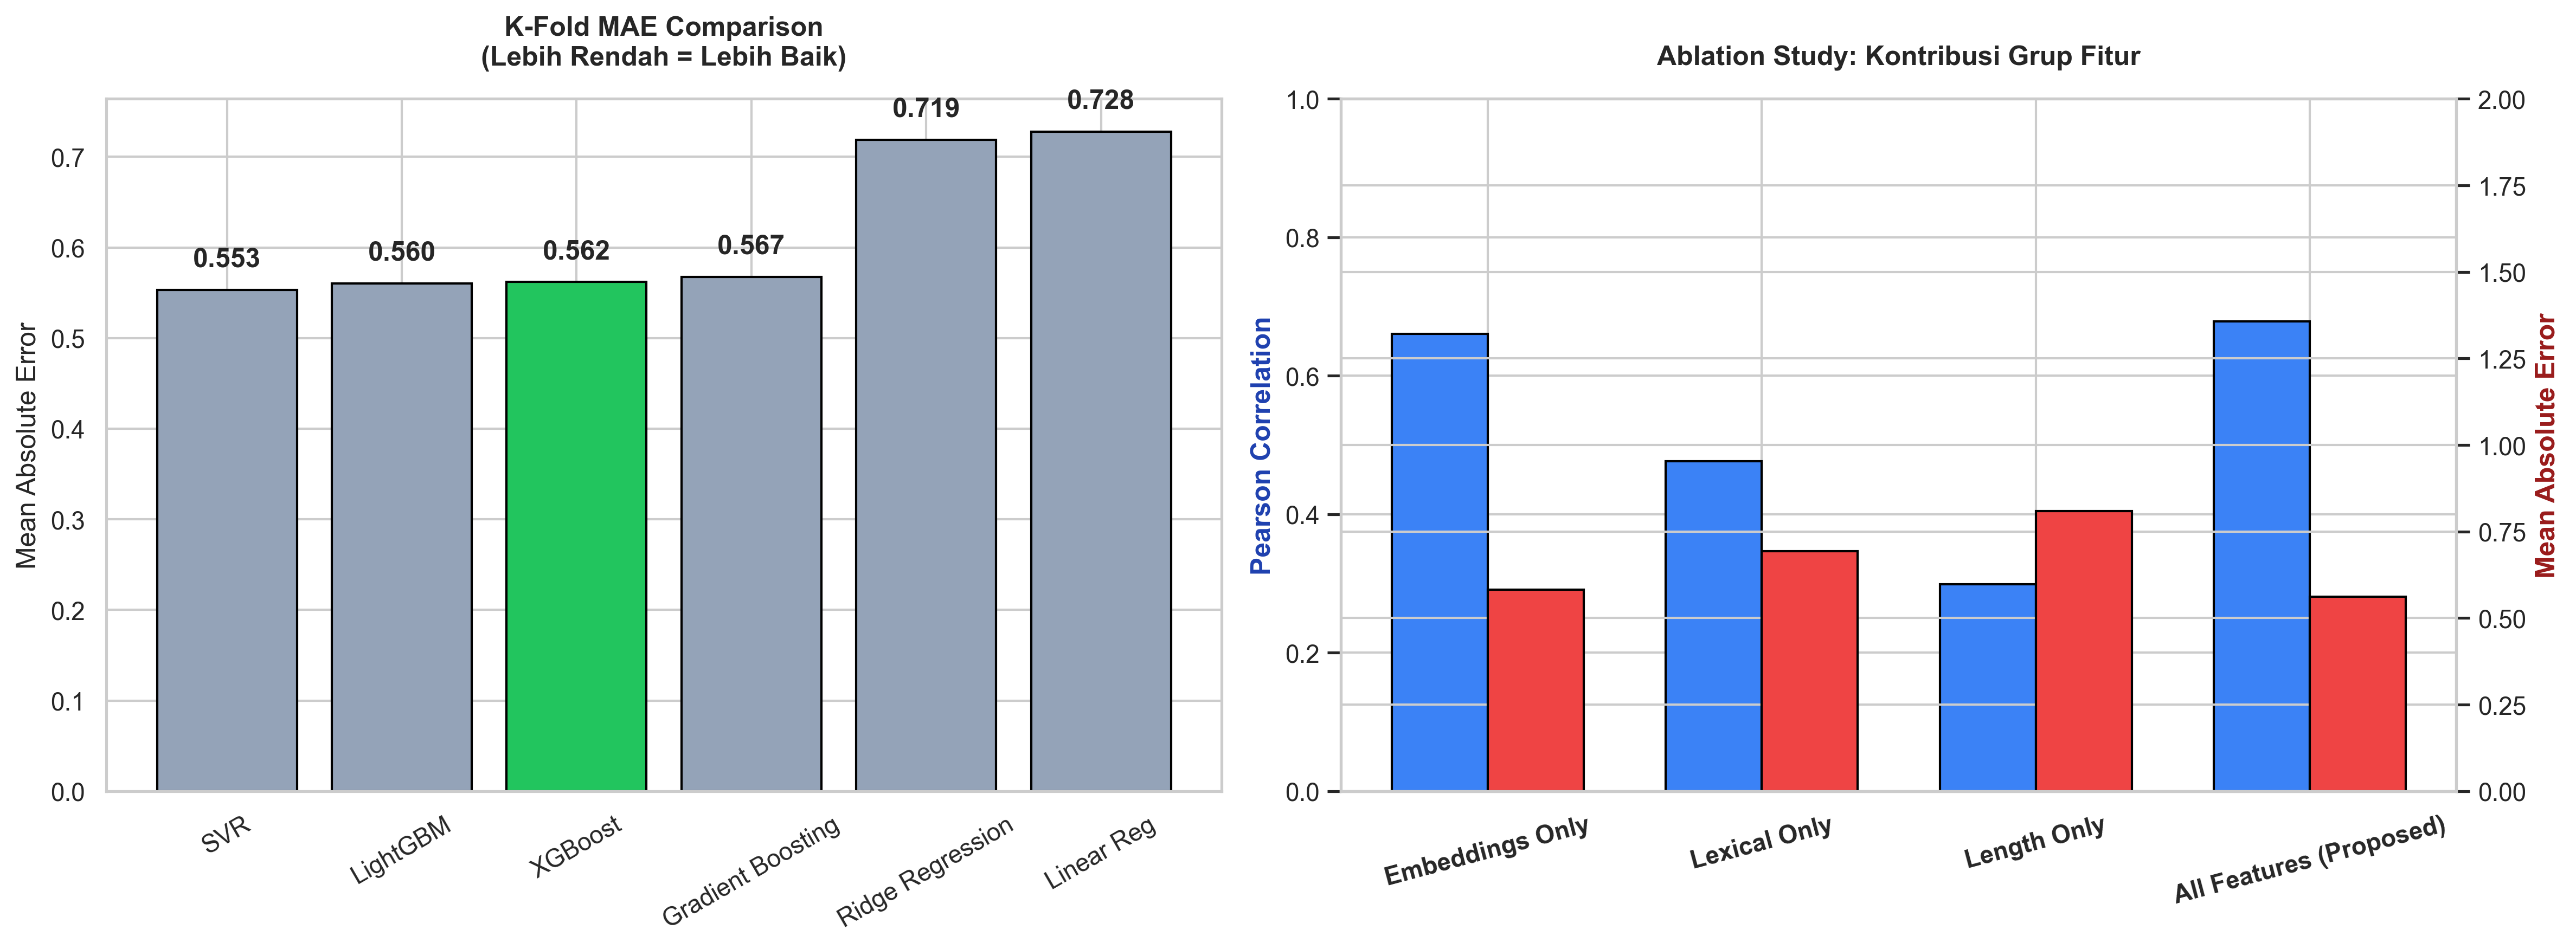

Menghitung SHAP Values...


PermutationExplainer explainer: 301it [03:26,  1.45it/s]                         


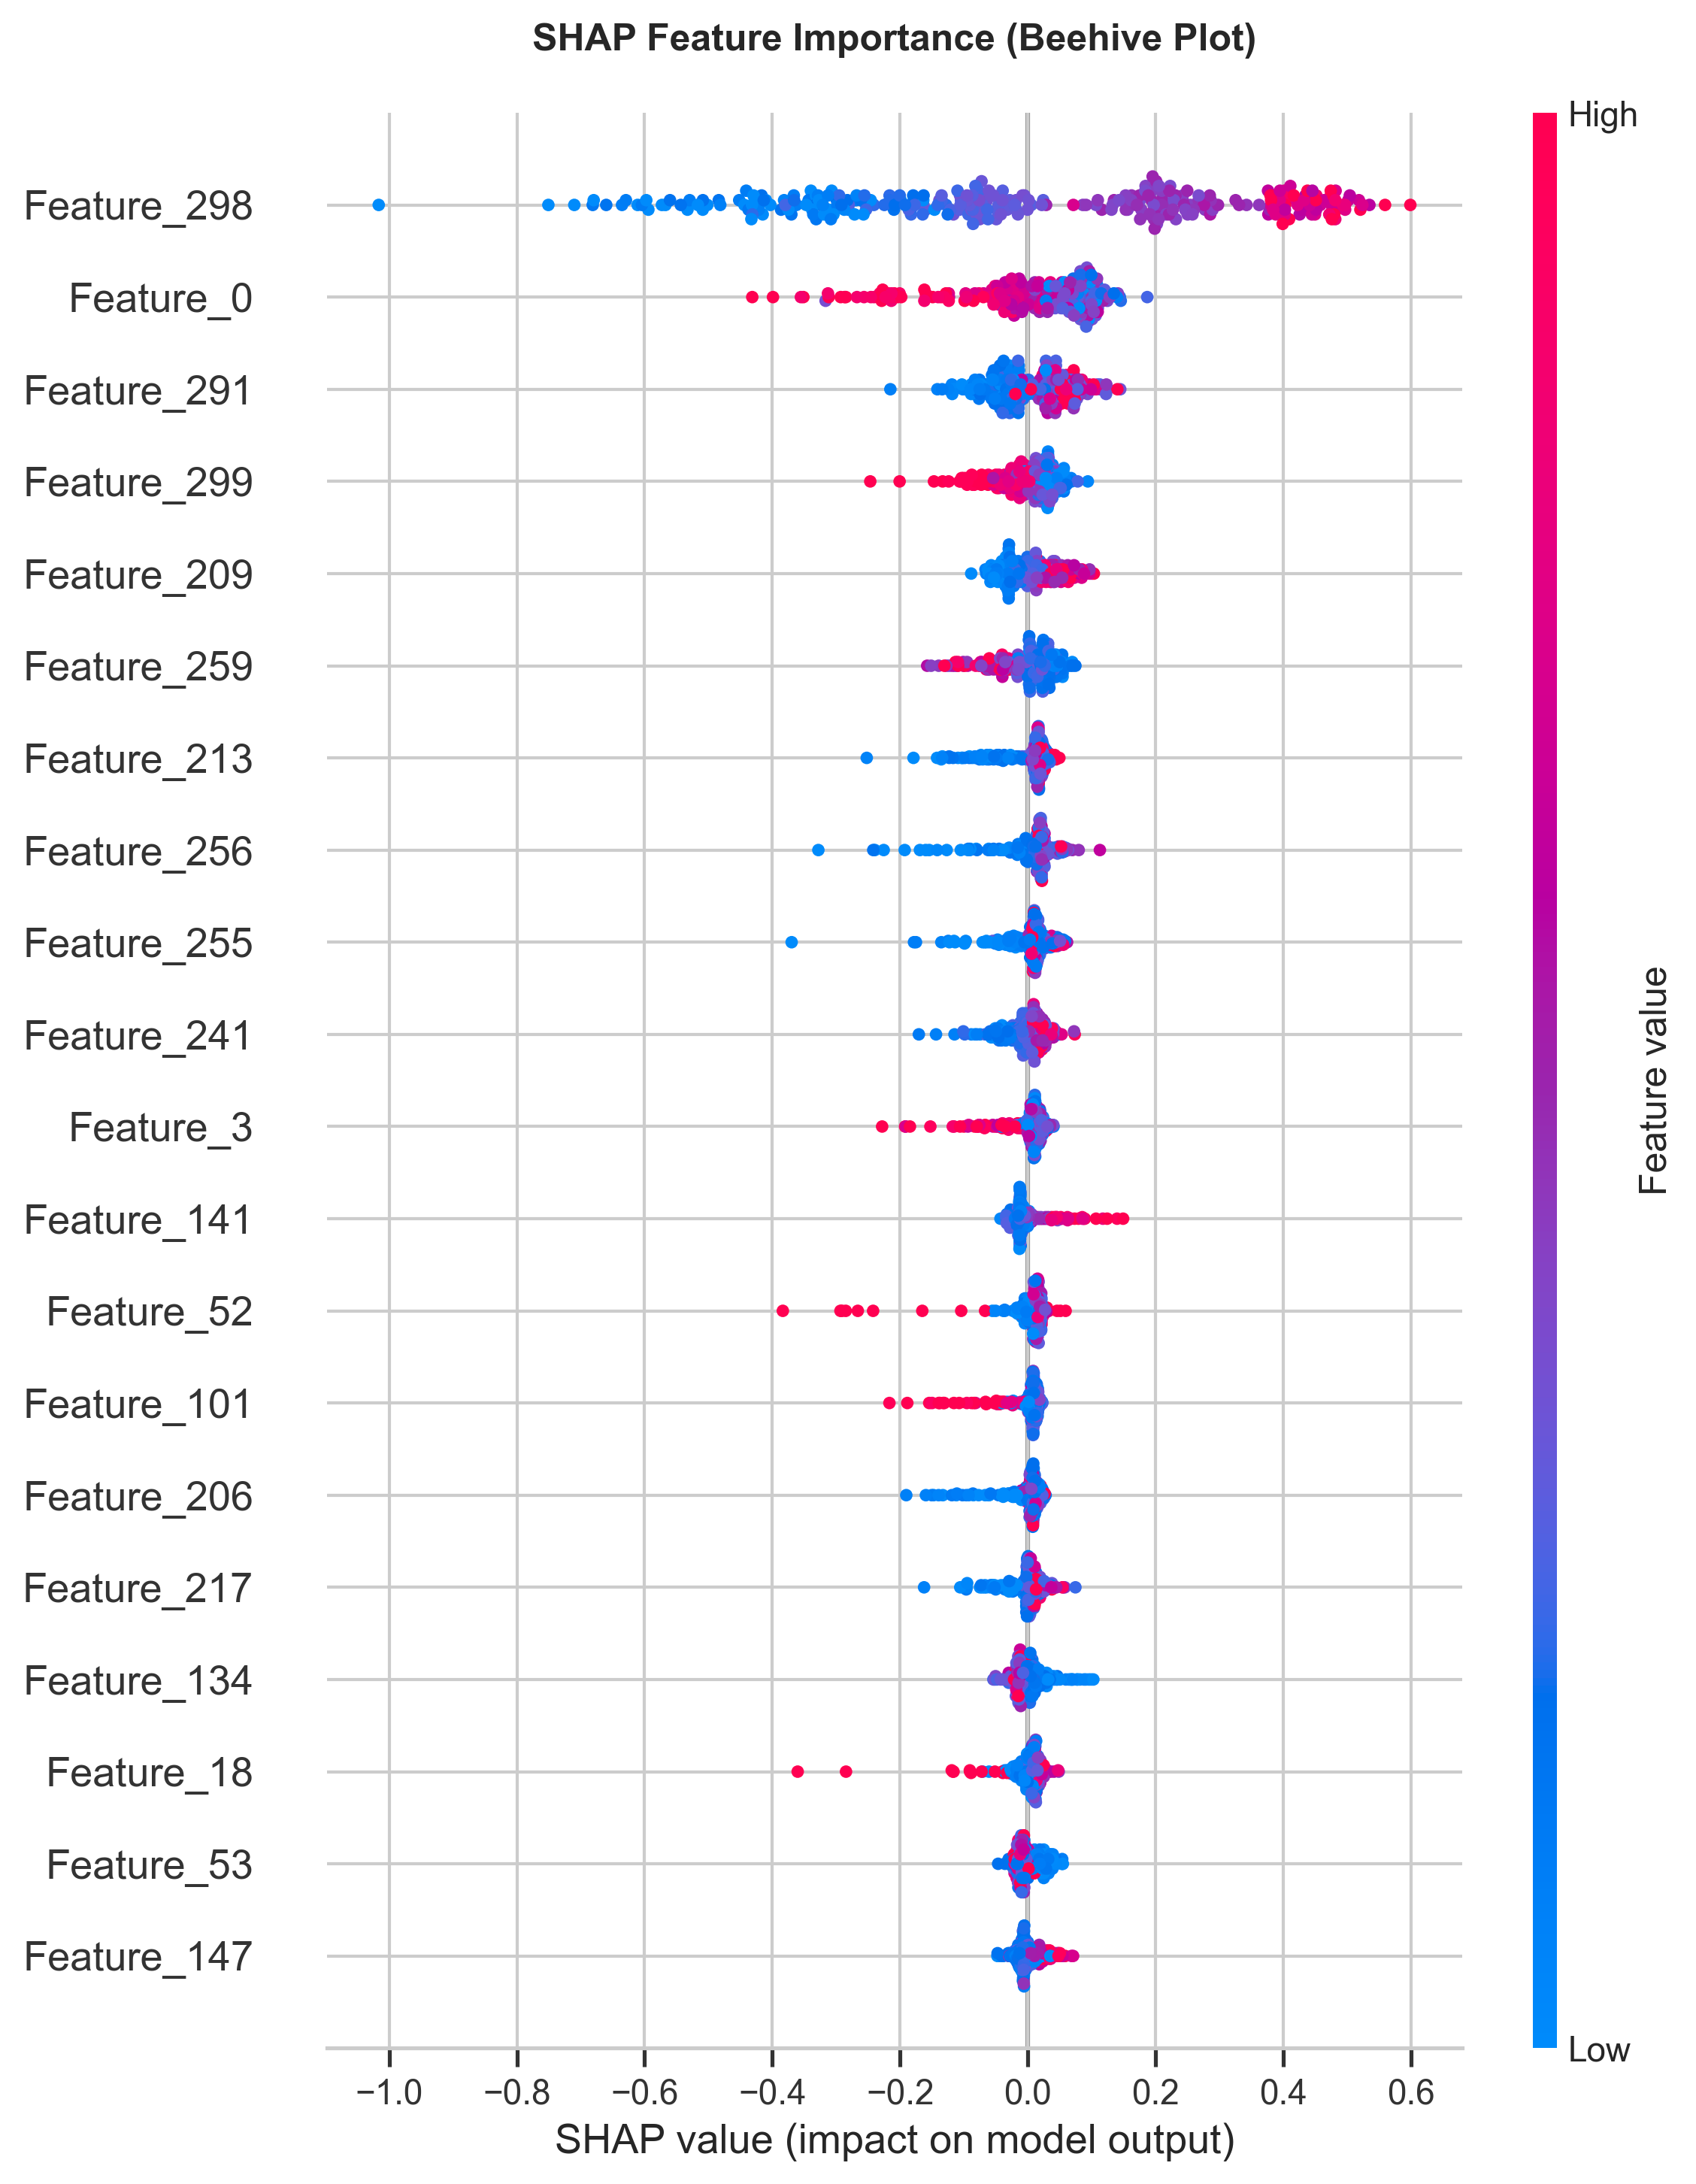

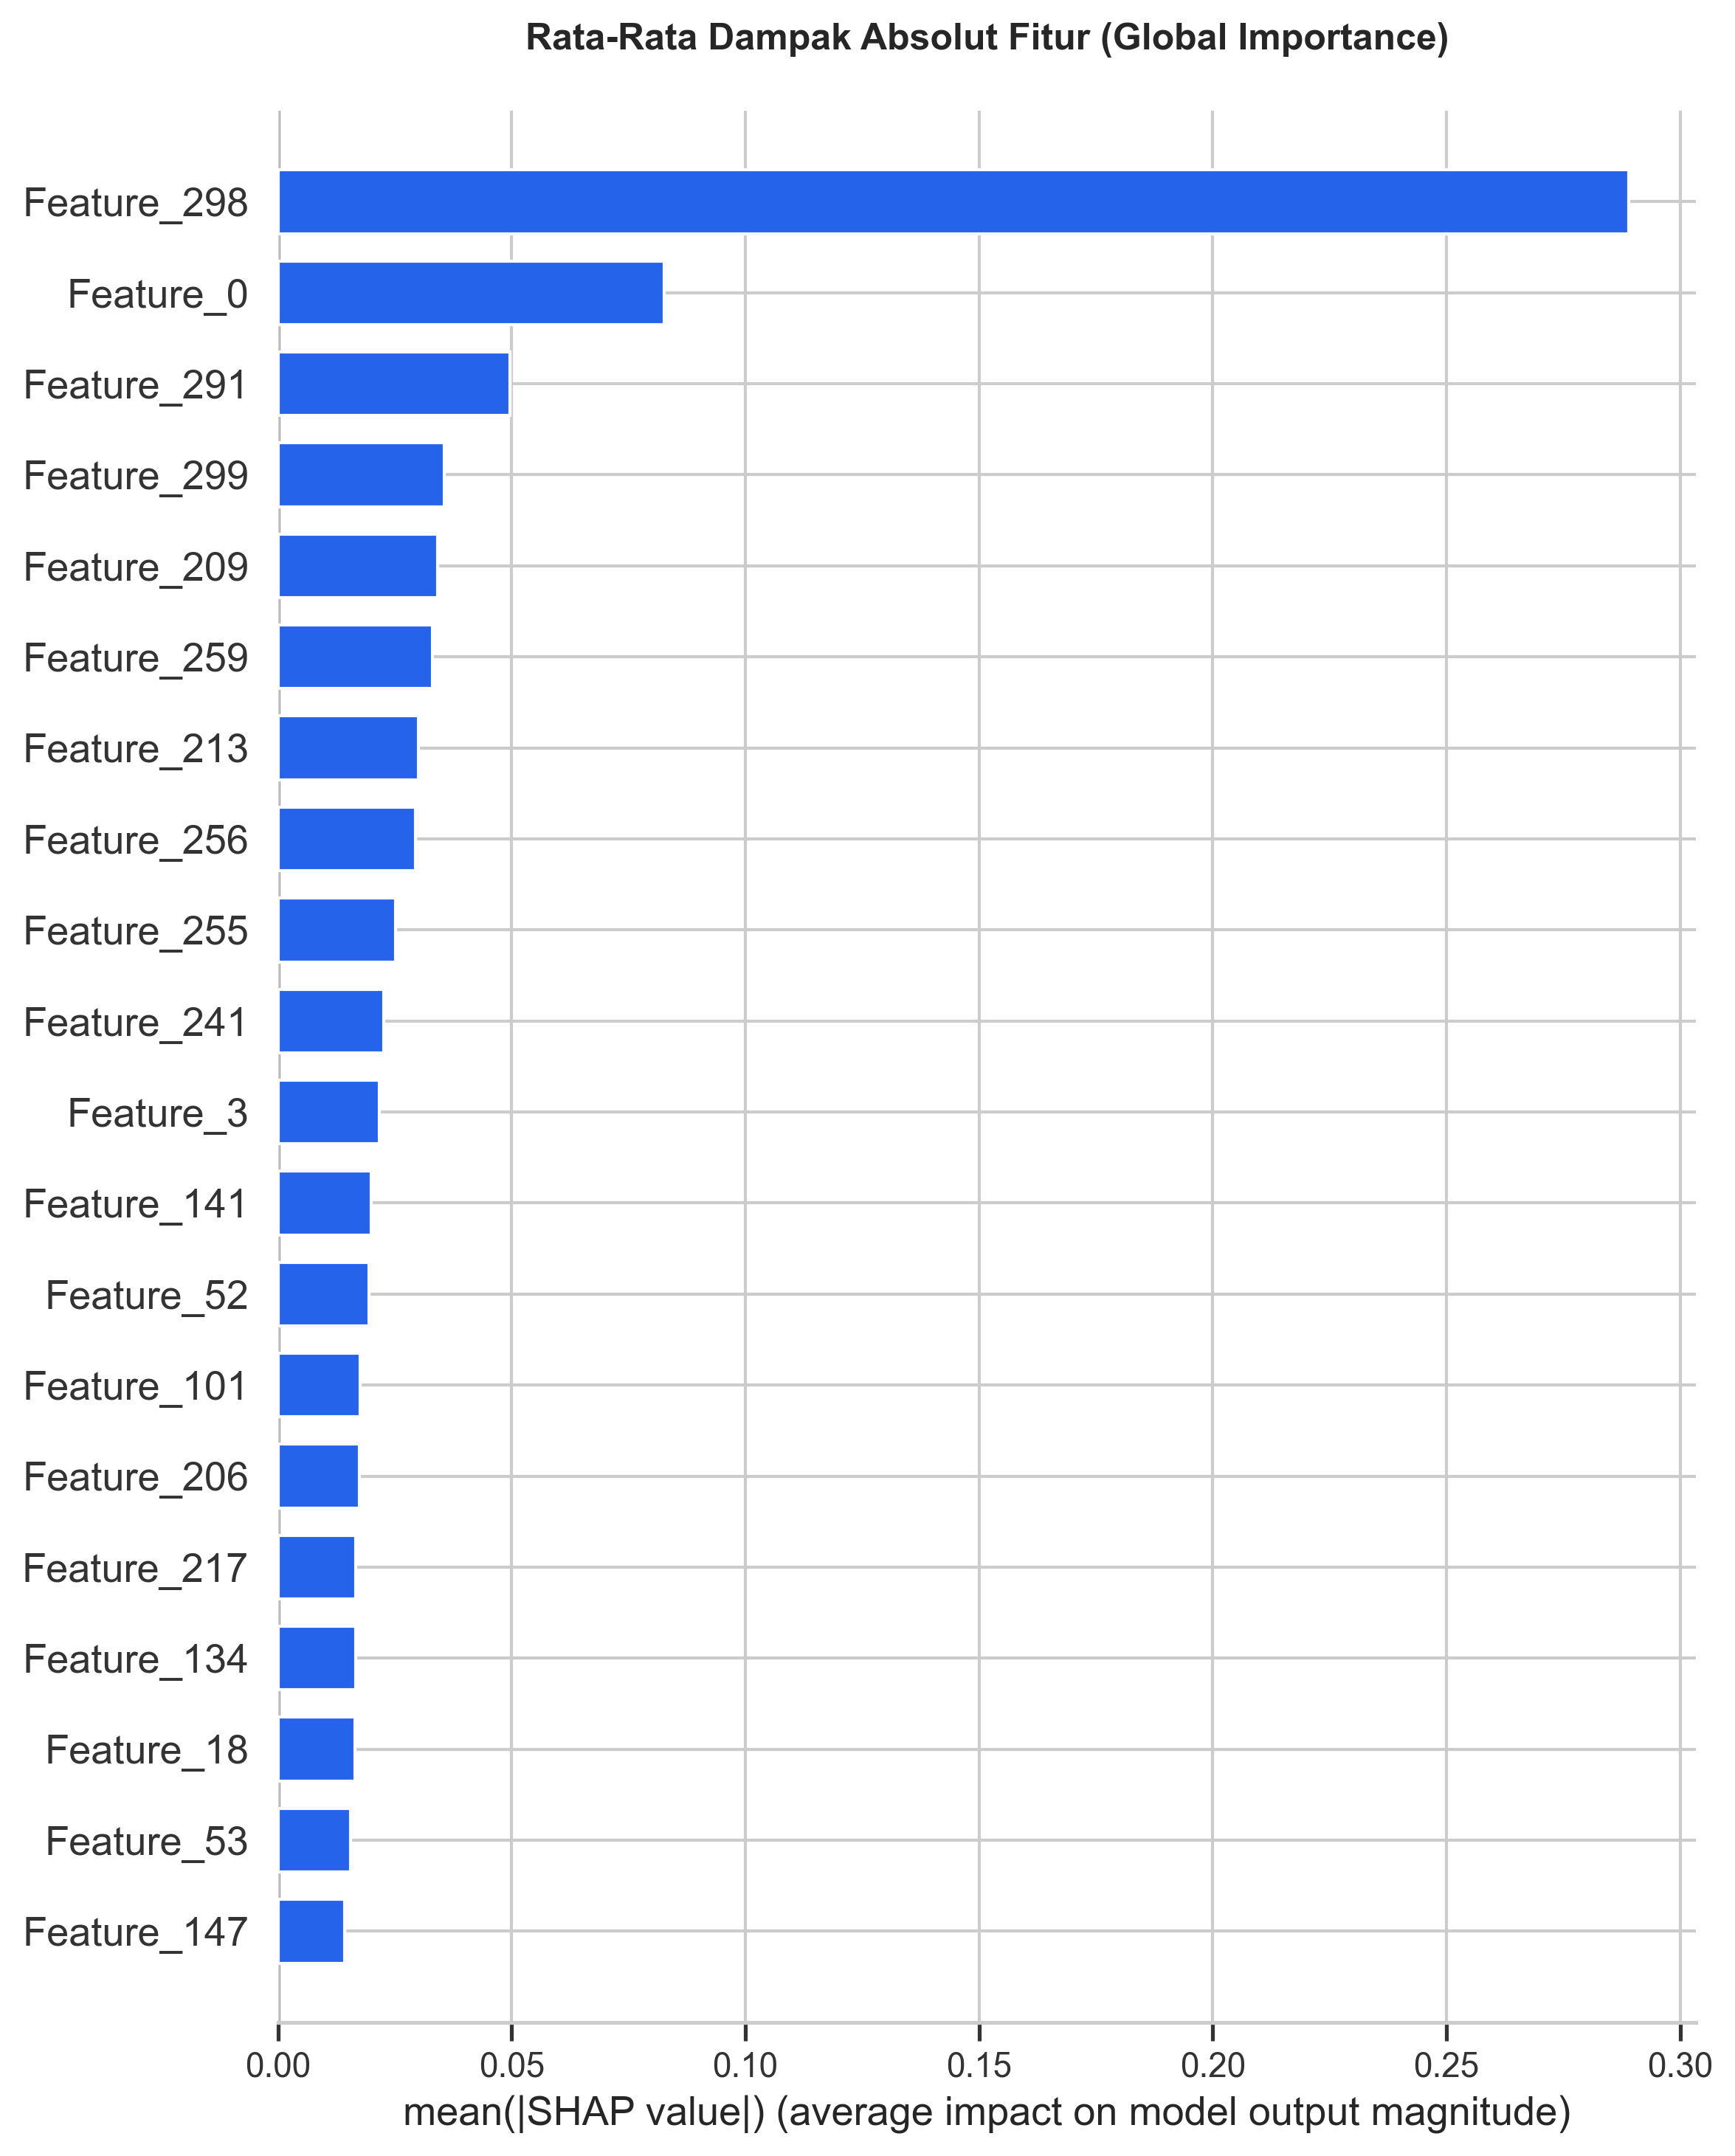

In [9]:
# ==========================================
# 1. VISUALISASI PERFORMA & ABLATION
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot A: MAE Comparison
model_names = summary_df.index.tolist()
clean_names = [n.replace("Baseline: ", "").replace(" (Proposed)", "") for n in model_names]
mae_vals = summary_df['MAE'].tolist()

colors = ['#22c55e' if 'XGBoost' in n else '#94a3b8' for n in model_names]
bars = ax1.bar(clean_names, mae_vals, color=colors, edgecolor='black')
ax1.set_title("K-Fold MAE Comparison\n(Lebih Rendah = Lebih Baik)", fontweight='bold', pad=15)
ax1.set_ylabel("Mean Absolute Error")
ax1.tick_params(axis='x', rotation=30)
for bar in bars:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.3f}', ha='center', va='bottom', fontweight='bold')

# Plot B: Ablation Study
x = np.arange(len(df_ablation))
width = 0.35
bar1 = ax2.bar(x - width/2, df_ablation['Pearson (↑)'], width, label='Pearson Corr (Kiri)', color='#3b82f6', edgecolor='black')
ax2.set_ylabel('Pearson Correlation', color='#1e40af', fontweight='bold')
ax2.set_ylim(0, 1.0)

ax3 = ax2.twinx()
bar2 = ax3.bar(x + width/2, df_ablation['MAE (↓)'], width, label='MAE (Kanan)', color='#ef4444', edgecolor='black')
ax3.set_ylabel('Mean Absolute Error', color='#991b1b', fontweight='bold')
ax3.set_ylim(0, 2.0)

ax2.set_xticks(x)
ax2.set_xticklabels(df_ablation['Feature Group'], fontweight='bold', rotation=15)
ax2.set_title('Ablation Study: Kontribusi Grup Fitur', fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig("performance_dashboard.png")
plt.show()

# ==========================================
# 2. VISUALISASI EXPLAINABLE AI (SHAP)
# ==========================================
print("Menghitung SHAP Values...")
feature_names_shap = [f"Feature_{i}" for i in range(X_full_sel.shape[1])]
X_shap_df = pd.DataFrame(X_full_sel, columns=feature_names_shap)

# Menggunakan 300 sampel data untuk efisiensi kalkulasi SHAP
X_shap_sample = X_shap_df.sample(300, random_state=RANDOM_SEED)
explainer = shap.Explainer(xgb_full.predict, X_shap_sample)

# FIX: Tambahkan parameter max_evals=1000 (harus > 601)
shap_values = explainer(X_shap_sample, max_evals=1000)

# Plot SHAP Beehive
fig = plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_shap_sample, show=False)
plt.title("SHAP Feature Importance (Beehive Plot)", fontweight='bold', pad=20)
plt.savefig("shap_summary.png")
plt.show()

# Plot SHAP Bar
fig = plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_shap_sample, plot_type="bar", color="#2563EB", show=False)
plt.title("Rata-Rata Dampak Absolut Fitur (Global Importance)", fontweight='bold', pad=20)
plt.savefig("shap_bar.png")
plt.show()